In [1]:
import pandas as pd
import seaborn as sns
#from IPython.display import Image, SVG, set_matplotlib_formats
from matplotlib import pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = [15, 7]
import multiprocessing
import numpy as np
#import allel
import warnings
import math
#import pybedtools
import scipy.stats as stats
from scipy.optimize import curve_fit
import joypy
warnings.filterwarnings('ignore')

In [7]:
f_list = ['AF_F_1','AF_F_2','AF_F_3','AF_F_4','AF_F_6','AF_F_7','AF_F_8','AF_F_9','AF_F_10']
m_list = ['AF_M_1','AF_M_2','AF_M_3','AF_M_4','AF_M_5','AF_M_6','AF_M_7','AF_M_8','AF_M_9','AF_M_10']
#f_list = ['AF_F_1','AF_F_2','AF_F_3','AF_F_4']
#m_list = ['AF_M_1','AF_M_2','AF_M_3','AF_M_4']
#f_list = ['AF_F_6','AF_F_7','AF_F_8','AF_F_9','AF_F_10']
#m_list = ['AF_M_6','AF_M_7','AF_M_8','AF_M_9','AF_M_10']
mixed = 'AF_F_5'
counts = 'TMM_normalized_TPMs.tsv'#'DESeq2_TPM_matrix.tsv'#'TMM_normalized_TPMs.tsv'#'rsem_TPM_agg.tsv'
bed = 'gene_lg.bed'
de_genes = 'DE_genes.txt'

gene_name = 'Geneid'
#gene_name = 'gene_id'

In [13]:
de_gene_list = pd.read_csv(de_genes)['Geneid'].to_list()

In [15]:
count_df = pd.read_csv(counts, sep='\t')
bed_df = pd.read_csv(bed, sep=' ', header=None).rename(columns={0:'LG',1:'transcript',2:'start',3:'stop'})
bed_df[gene_name] = bed_df['transcript'].str.split('.', expand=True)[0]
bed_df['length'] = bed_df['stop'] - bed_df['start']
A_list = ['OX359245.1','OX359246.1','OX359247.1','OX359248.1']
X_list = ['OX359249.1','OX359250.1']
linkages = ['A','X']
conditions = [bed_df['LG'].isin(A_list), 
             bed_df['LG'].isin(X_list),
            ]
bed_df['linkage'] = np.select(conditions, linkages, default='unplaced')
unplaced_df = bed_df[bed_df['linkage']=='unplaced']
bed_df = bed_df[bed_df['linkage']!='unplaced']
count_df = count_df.merge(bed_df[[gene_name,'linkage','length']], on=gene_name,how='outer')
count_df.drop_duplicates(subset=gene_name,inplace=True)
count_df['f_mean'] = count_df[f_list].mean(axis=1)
count_df['m_mean'] = count_df[m_list].mean(axis=1)
count_df['log2_f_mean'] = np.log(count_df[f_list].mean(axis=1))
count_df['log2_m_mean'] = np.log(count_df[m_list].mean(axis=1))
count_df = count_df[(count_df['f_mean']>0) & (count_df['m_mean']>0)]

In [16]:
count_df = count_df[(count_df['log2_f_mean']>count_df['log2_f_mean'].quantile(0.05)) & (count_df['log2_f_mean']<count_df['log2_f_mean'].quantile(0.95))]
count_df = count_df[(count_df['log2_m_mean']>count_df['log2_m_mean'].quantile(0.05)) & (count_df['log2_m_mean']<count_df['log2_m_mean'].quantile(0.95))]
count_df['m/f_mean'] = count_df['m_mean']/count_df['f_mean']
count_df['log2_m/f_mean'] = count_df['log2_m_mean']/count_df['log2_f_mean']
count_df.replace(np.inf, np.nan, inplace=True)
count_df.groupby('linkage')[['f_mean','m_mean']].describe()

f_mean                                                       \
          count       mean        std       min       25%        50%   
linkage                                                                
A        6774.0  25.792477  31.309951  1.470849  7.078577  14.630164   
X        2784.0  27.458690  29.883678  1.478765  8.706432  17.308671   

                                m_mean                                  \
               75%         max   count       mean        std       min   
linkage                                                                  
A        30.966589  245.189076  6774.0  29.823260  30.354628  2.636936   
X        34.592331  235.591378  2784.0  33.427849  30.946816  2.640799   

                                                      
               25%        50%        75%         max  
linkage                                               
A         8.754496  18.511990  39.553514  151.947703  
X        11.450252  22.964838  44.019096  151.531357

In [22]:
6774+2784

9558

In [28]:
count_df

,Geneid,AF_F_1,AF_F_10,AF_F_2,AF_F_3,AF_F_4,AF_F_5,AF_F_6,AF_F_7,AF_F_8,...,AF_M_8,AF_M_9,linkage,length,f_mean,m_mean,log2_f_mean,log2_m_mean,m/f_mean,log2_m/f_mean
0,g100,1.089168,2.318416,2.540751,2.052335,2.412374,2.810688,1.167159,0.887211,0.791436,...,1.592569,0.813121,NaN,NaN,1.614395,2.973834,0.478960,1.089852,1.842073,2.275453
4,g10001,54.032469,52.562665,45.360444,41.817389,24.105166,28.012642,19.035353,39.686670,14.862435,...,77.706178,53.401505,A,57783.0,56.738830,71.597243,4.038459,4.271057,1.261874,1.057596
5,g10002,127.361922,27.097898,53.114360,19.290597,33.239914,30.531458,48.933553,25.792016,30.438345,...,185.483458,143.147646,A,1219.0,49.280560,100.481478,3.897530,4.609973,2.038968,1.182794
14,g10007,7.471723,2.669263,2.847712,2.475052,1.442247,1.480479,4.258959,2.125322,2.721005,...,15.502279,7.271932,A,1447.0,4.096922,7.445355,1.410236,2.007590,1.817305,1.423585
16,g10008,3.950811,2.346906,3.648402,2.709049,3.352140,4.410851,3.219496,2.574591,2.097272,...,5.859358,11.856942,A,1640.0,2.902336,5.108866,1.065516,1.630978,1.760260,1.530693
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30089,g9988,12.244175,18.934274,18.354608,10.819114,10.367770,14.746510,12.375668,16.667963,12.684784,...,25.087761,12.831878,A,1014.0,14.436698,16.533199,2.669773,2.805370,1.145220,1.050790
30092,g999,75.867748,64.396236,72.430854,82.980885,120.766579,65.333728,51.980411,84.510715,44.480444,...,68.033162,52.946434,A,1333.0,73.793785,75.259673,4.301275,4.320944,1.019865,1.004573
30093,g9990,21.396534,28.875738,23.391856,18.236223,22.825446,24.434694,22.921417,23.686288,24.519127,...,25.029652,20.458932,A,3214.0,24.992005,20.236567,3.218556,3.007491,0.809722,0.934423
30094,g9991,36.681742,57.931306,39.969736,65.531368,61.515557,34.997404,25.498568,67.566551,31.391332,...,74.542567,40.354094,A,1916.0,54.706469,70.177792,4.001982,4.251032,1.282806,1.062232


In [31]:
print(count_df[count_df['linkage']=='A']['log2_m_mean'].mean())
print(count_df[count_df['linkage']=='A']['log2_f_mean'].mean())
print(count_df[count_df['linkage']=='A']['log2_m/f_mean'].mean())

3.1077616204766483
2.8436361241321326
1.1818642089284435


In [ ]:
# Do we still see this excluding DE genes?

In [38]:
print(count_df[count_df['linkage']=='A']['log2_m_mean'].mean())
print(count_df[count_df['linkage']=='X']['log2_m_mean'].mean())
print(count_df[count_df['linkage']=='A']['log2_f_mean'].mean())
print(count_df[count_df['linkage']=='X']['log2_f_mean'].mean())

2.926302020089658
3.1077616204766483
2.708106806041599
2.8436361241321326


In [40]:
2.84/2.71

1.047970479704797

In [39]:
stats.mannwhitneyu(count_df[count_df['linkage']=='X']['log2_f_mean'],count_df[count_df['linkage']=='A']['log2_f_mean'])

MannwhitneyuResult(statistic=np.float64(10182947.5), pvalue=np.float64(7.847264091807561e-10))

In [42]:
count_df

,Geneid,AF_F_1,AF_F_10,AF_F_2,AF_F_3,AF_F_4,AF_F_5,AF_F_6,AF_F_7,AF_F_8,...,AF_M_8,AF_M_9,linkage,length,f_mean,m_mean,log2_f_mean,log2_m_mean,m/f_mean,log2_m/f_mean
0,g100,1.089168,2.318416,2.540751,2.052335,2.412374,2.810688,1.167159,0.887211,0.791436,...,1.592569,0.813121,NaN,NaN,1.614395,2.973834,0.478960,1.089852,1.842073,2.275453
4,g10001,54.032469,52.562665,45.360444,41.817389,24.105166,28.012642,19.035353,39.686670,14.862435,...,77.706178,53.401505,A,57783.0,56.738830,71.597243,4.038459,4.271057,1.261874,1.057596
5,g10002,127.361922,27.097898,53.114360,19.290597,33.239914,30.531458,48.933553,25.792016,30.438345,...,185.483458,143.147646,A,1219.0,49.280560,100.481478,3.897530,4.609973,2.038968,1.182794
14,g10007,7.471723,2.669263,2.847712,2.475052,1.442247,1.480479,4.258959,2.125322,2.721005,...,15.502279,7.271932,A,1447.0,4.096922,7.445355,1.410236,2.007590,1.817305,1.423585
16,g10008,3.950811,2.346906,3.648402,2.709049,3.352140,4.410851,3.219496,2.574591,2.097272,...,5.859358,11.856942,A,1640.0,2.902336,5.108866,1.065516,1.630978,1.760260,1.530693
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30089,g9988,12.244175,18.934274,18.354608,10.819114,10.367770,14.746510,12.375668,16.667963,12.684784,...,25.087761,12.831878,A,1014.0,14.436698,16.533199,2.669773,2.805370,1.145220,1.050790
30092,g999,75.867748,64.396236,72.430854,82.980885,120.766579,65.333728,51.980411,84.510715,44.480444,...,68.033162,52.946434,A,1333.0,73.793785,75.259673,4.301275,4.320944,1.019865,1.004573
30093,g9990,21.396534,28.875738,23.391856,18.236223,22.825446,24.434694,22.921417,23.686288,24.519127,...,25.029652,20.458932,A,3214.0,24.992005,20.236567,3.218556,3.007491,0.809722,0.934423
30094,g9991,36.681742,57.931306,39.969736,65.531368,61.515557,34.997404,25.498568,67.566551,31.391332,...,74.542567,40.354094,A,1916.0,54.706469,70.177792,4.001982,4.251032,1.282806,1.062232


In [45]:
print(count_df[(count_df['linkage']=='A') & ~(count_df['Geneid'].isin(de_gene_list))]['log2_m_mean'].mean())
print(count_df[(count_df['linkage']=='X') & ~(count_df['Geneid'].isin(de_gene_list))]['log2_m_mean'].mean())
print(count_df[(count_df['linkage']=='A') & ~(count_df['Geneid'].isin(de_gene_list))]['log2_f_mean'].mean())
print(count_df[(count_df['linkage']=='X') & ~(count_df['Geneid'].isin(de_gene_list))]['log2_f_mean'].mean())

2.908694831057697
3.0974747143785737
2.697666273205003
2.8396260686046295


In [47]:
2.91/3.09

0.9417475728155341

In [48]:
2.80/2.83

0.989399293286219

In [50]:
stats.mannwhitneyu(count_df[(count_df['linkage']=='X') & ~(count_df['Geneid'].isin(de_gene_list))]['log2_m_mean'],count_df[(count_df['linkage']=='A') & ~(count_df['Geneid'].isin(de_gene_list))]['log2_m_mean'])

MannwhitneyuResult(statistic=np.float64(4375783.0), pvalue=np.float64(8.823288325190412e-12))

(0.0, 5.0)

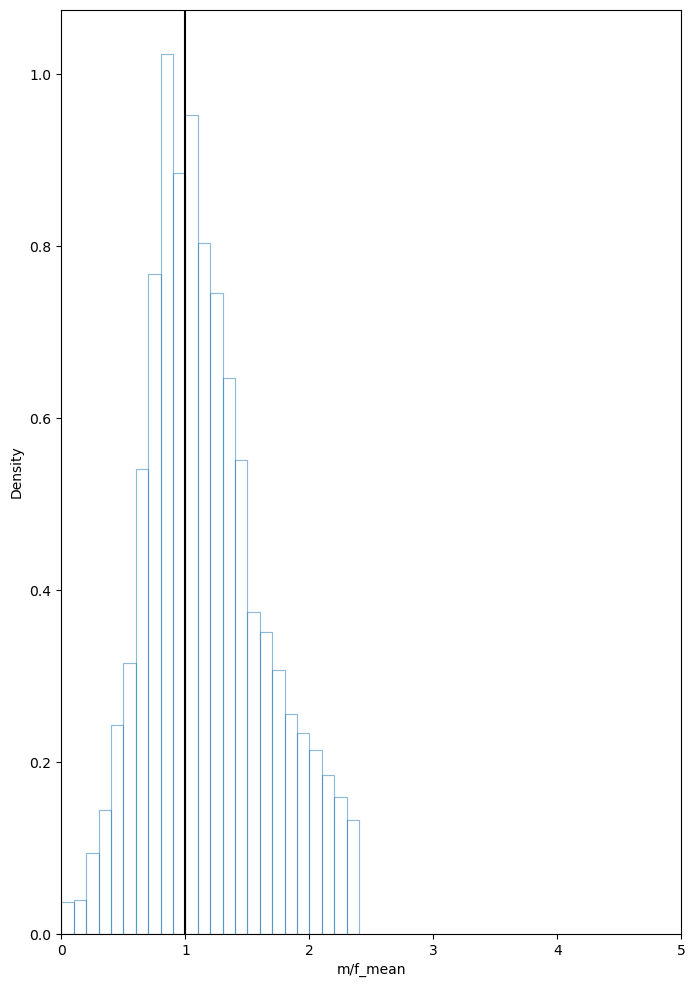

In [17]:
melt_df = pd.melt(count_df[[gene_name,'linkage','f_mean','m_mean']], id_vars='linkage',value_vars=['f_mean','m_mean'])
#melt_df_2 = pd.melt(count_df[['gene_id','linkage','m/f_mean']], id_vars='linkage',value_vars=['m/f_mean'])
#melt_df_2['value'] = np.log2(melt_df_2['value'])
bins = np.arange(-2.5, 2.5, 0.1)
fig, axs = plt.subplots(figsize=(8,12))

sns.histplot(data=count_df[~count_df[gene_name].isin(de_gene_list)]['m/f_mean'],
            stat='density',
            fill=None,
            #kde=True,
            bins=bins,
            alpha=0.5)

plt.axvline(x=1, color='black')
axs.set_xlim(0,5)

In [21]:
melt_df

,linkage,variable,value
0,NaN,f_mean,1.614395
1,A,f_mean,56.738830
2,A,f_mean,49.280560
3,A,f_mean,4.096922
4,A,f_mean,2.902336
...,...,...,...
19937,A,m_mean,16.533199
19938,A,m_mean,75.259673
19939,A,m_mean,20.236567
19940,A,m_mean,70.177792


A line: 0.2276669400037375
X line: 0.26000849834403394


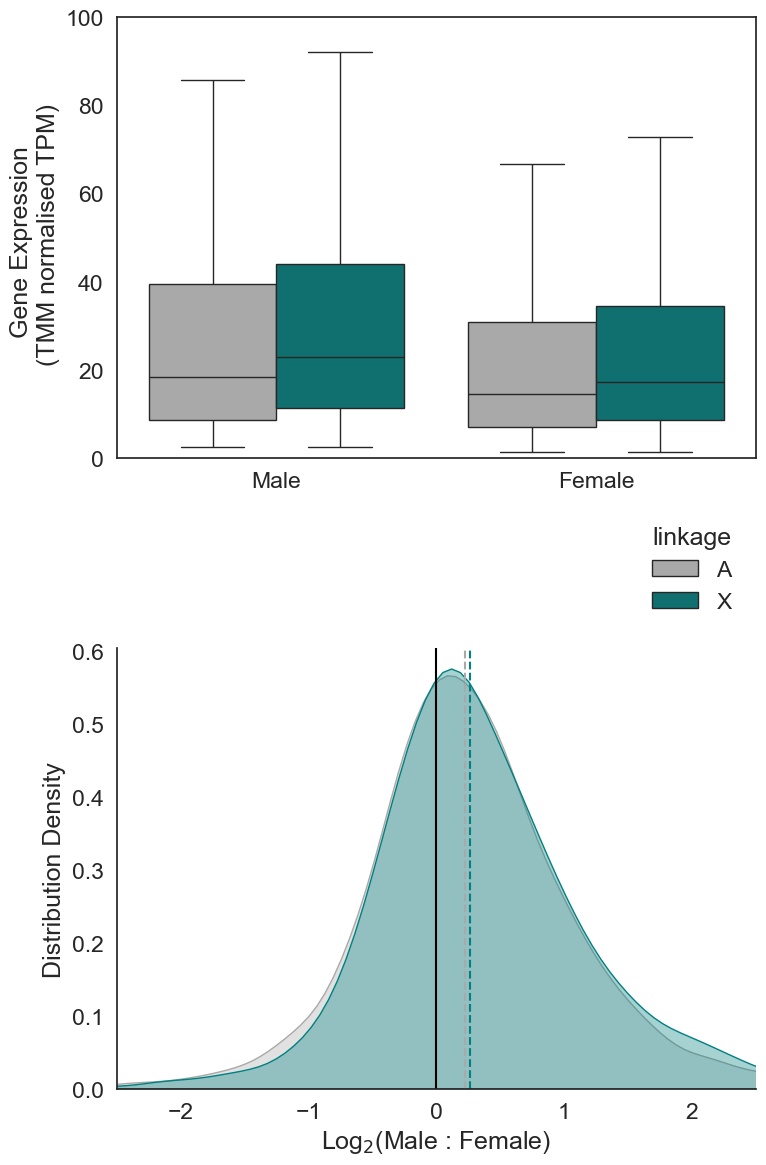

In [18]:
sns.set(font_scale=1.5, style = 'white')

fig, axs = plt.subplots(nrows=2, figsize=(8,12))

bins = np.arange(-2.5, 2.5, 0.1)

box_ax = axs[0]
dens_ax = axs[1]

sns.boxplot(data=melt_df,
               x='variable',
               y='value',
               hue='linkage',
               order=['m_mean','f_mean'],
               palette={'A': 'darkgray', 'X': 'teal'},
               ax= box_ax,
               showfliers=False
              )

box_ax.set_ylim(0,100)
box_ax.set_ylabel("Gene Expression \n (TMM normalised TPM)")
box_ax.set_xlabel('')
box_ax.set_xticklabels(['Male','Female'])

#sns.histplot(data=np.log2(count_df[count_df['linkage']=='A']['m/f_mean']),
#            stat='density',
#            fill=None,
#            kde=True,
#            bins=bins,
#            label='Autosomes',
#            color='darkgray',
#            alpha=0.5,
#            ax=dens_ax)

sns.kdeplot(data=np.log2(count_df[count_df['linkage']=='A']['m/f_mean']),
            fill=True,
            label='A',
            alpha=0.35,
            color = 'darkgray',
            ax=dens_ax)

A_line = np.median(np.log2(count_df[count_df['linkage']=='A']['m/f_mean']))
print(f'A line: {A_line}')
dens_ax.axvline(x=A_line, color='darkgray', linestyle='--')

#sns.histplot(data=np.log2(count_df[count_df['linkage']=='X']['m/f_mean']),
#            stat='density',
#            fill=None,
#            kde=True,
##            color='teal',
#            bins=bins,
#            label='X',
#            alpha=0.5,
#            ax=dens_ax)

sns.kdeplot(data=np.log2(count_df[count_df['linkage']=='X']['m/f_mean']),
            fill=True,
            label='X',
            alpha=0.35,
            color='teal',
            ax=dens_ax)


X_line = np.median(np.log2(count_df[count_df['linkage']=='X']['m/f_mean']))
print(f'X line: {X_line}')
dens_ax.axvline(x=X_line, color='teal', linestyle='--')

dens_ax.set_xlim(-2.5,2.5)
dens_ax.set_xlabel('Log$_{2}$(Male : Female)')
dens_ax.set_ylabel('Distribution Density')
dens_ax.axvline(x=0, color='black', linestyle = '-')

sns.move_legend(box_ax, "center", bbox_to_anchor=(0.9, -0.25), frameon=False)
sns.despine(ax=dens_ax)
dens_ax.set_zorder(-1)
plt.tight_layout()

plt.savefig("dosage_comp.png", dpi=300, bbox_inches='tight')
plt.savefig("dosage_comp.pdf", bbox_inches='tight')
plt.savefig("dosage_comp.svg", bbox_inches='tight')

In [19]:
f_a_med = melt_df[(melt_df['linkage']=='A') & (melt_df['variable']=='f_mean')]['value'].median()
f_x_med = melt_df[(melt_df['linkage']=='X') & (melt_df['variable']=='f_mean')]['value'].median()
m_a_med = melt_df[(melt_df['linkage']=='A') & (melt_df['variable']=='m_mean')]['value'].median()
m_x_med = melt_df[(melt_df['linkage']=='X') & (melt_df['variable']=='m_mean')]['value'].median()

In [20]:
print(f'Observed male X/A = {m_x_med/m_a_med}')
print(f'Observed female X/A = {f_x_med/f_a_med}')

Observed male X/A = 1.2405386078130671
Observed female X/A = 1.1830811611002445


In [89]:
ad_df = pd.read_csv('ad.csv', sep=',', header=None, names = ['file','AD1','AD2'])
ad_df['sample'] = ad_df['file'].str.split('.', expand=True)[0]

In [90]:
order = ['AF_F_1', 'AF_F_2', 'AF_F_3', 'AF_F_4', 'AF_F_5',
       'AF_F_6', 'AF_F_7', 'AF_F_8', 'AF_F_9', 'AF_F_10','AF_M_1',
       'AF_M_2', 'AF_M_3', 'AF_M_4', 'AF_M_5', 'AF_M_6', 'AF_M_7',
       'AF_M_8', 'AF_M_9','AF_M_10']
order_singles = ['AF_F_6', 'AF_F_7', 'AF_F_8', 'AF_F_9', 'AF_F_10', 'AF_M_6', 'AF_M_7',
       'AF_M_8', 'AF_M_9','AF_M_10']

In [91]:
ad_df['AD1_frac'] = ad_df['AD1']/(ad_df['AD1']+ad_df['AD2'])
ad_df['AD2_frac'] = ad_df['AD2']/(ad_df['AD1']+ad_df['AD2'])

In [92]:
ad_df['sex'] = ad_df['sample'].str.split('_',expand=True)[1]
ad_df['sex'].replace({'F':'Female','M':'Male'}, inplace=True)

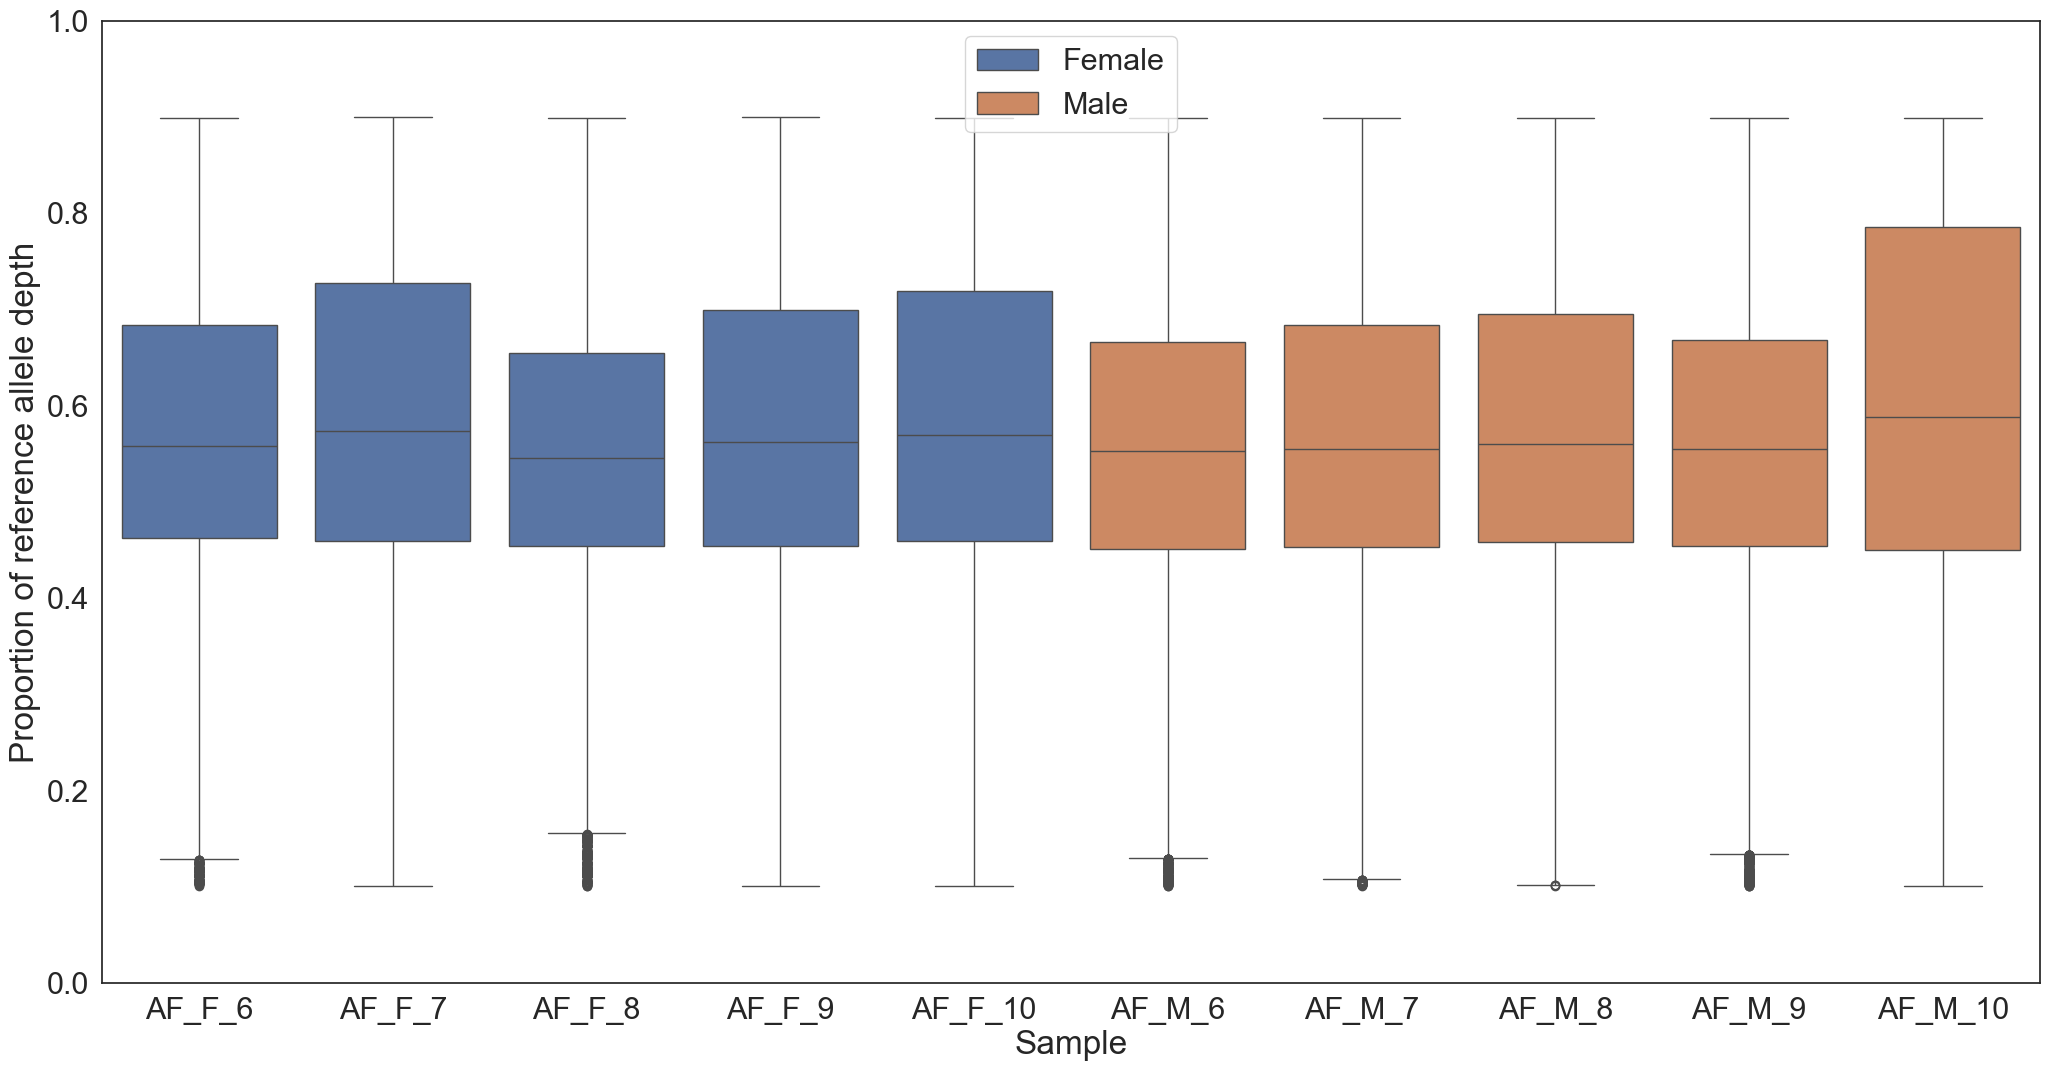

In [93]:
sns.set(font_scale=2, style = 'white')

fig, axs = plt.subplots(figsize=(25,12.5))

sns.boxplot(data=ad_df[(ad_df['AD1_frac']>0.1) & (ad_df['AD1_frac']<0.9)],
           x = 'sample',
           y = 'AD1_frac',
           order=order_singles,
           hue='sex')

axs.set_ylim(0,1)
axs.set_ylabel('Proportion of reference allele depth')
axs.set_xlabel('Sample')
axs.legend(loc='upper center')

fig.savefig("AD.pdf", dpi = 200)
fig.savefig("AD.png", dpi = 200)

<Axes: xlabel='AD1_frac', ylabel='Count'>

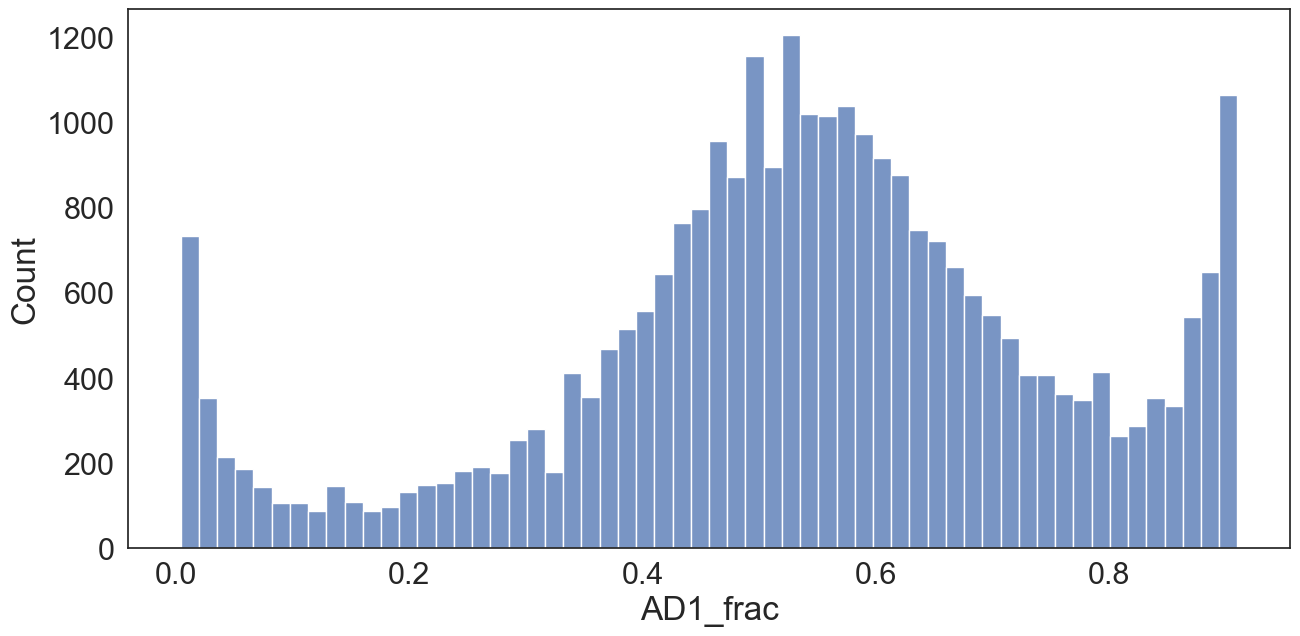

In [94]:
sns.histplot(ad_df[(ad_df['sample']=='AF_M_6') & (ad_df['AD1_frac']>0) & (ad_df['AD1_frac']<0.91)]['AD1_frac'])

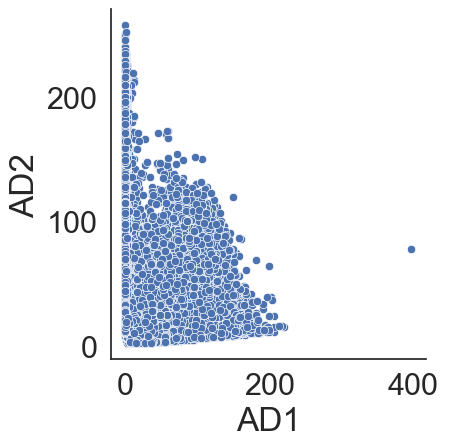

In [31]:
sns.relplot(data = ad_df[ad_df['sample']=='AF_M_6'],
            x = 'AD1',
            y = 'AD2')

In [95]:
ad_df['sum'] = ad_df['AD1'] + ad_df['AD2']
ad_df = ad_df[(ad_df['sum'] > 8)]
#ad_df = ad_df[(ad_df['AD1'] > 2) & (ad_df['AD2'] > 2) & (ad_df['sum'] > 8)]
ad_df['linkage'] = np.tile(['Autosomes', 'Xs'], len(ad_df))[:len(ad_df)]

In [96]:
ad_df

,file,AD1,AD2,sample,AD1_frac,AD2_frac,sex,sum,linkage
0,AF_F_10.AD.csv,9,20,AF_F_10,0.310345,0.689655,Female,29,Autosomes
1,AF_F_10.AD.csv,5,8,AF_F_10,0.384615,0.615385,Female,13,Xs
2,AF_F_10.AD.csv,0,12,AF_F_10,0.000000,1.000000,Female,12,Autosomes
3,AF_F_10.AD.csv,13,10,AF_F_10,0.565217,0.434783,Female,23,Xs
4,AF_F_10.AD.csv,0,28,AF_F_10,0.000000,1.000000,Female,28,Autosomes
...,...,...,...,...,...,...,...,...,...
1069497,AF_M_9.AD.csv,8,2,AF_M_9,0.800000,0.200000,Male,10,Xs
1069498,AF_M_9.AD.csv,0,117,AF_M_9,0.000000,1.000000,Male,117,Autosomes
1069499,AF_M_9.AD.csv,0,14,AF_M_9,0.000000,1.000000,Male,14,Xs
1069500,AF_M_9.AD.csv,0,182,AF_M_9,0.000000,1.000000,Male,182,Autosomes


<Figure size 600x400 with 0 Axes>

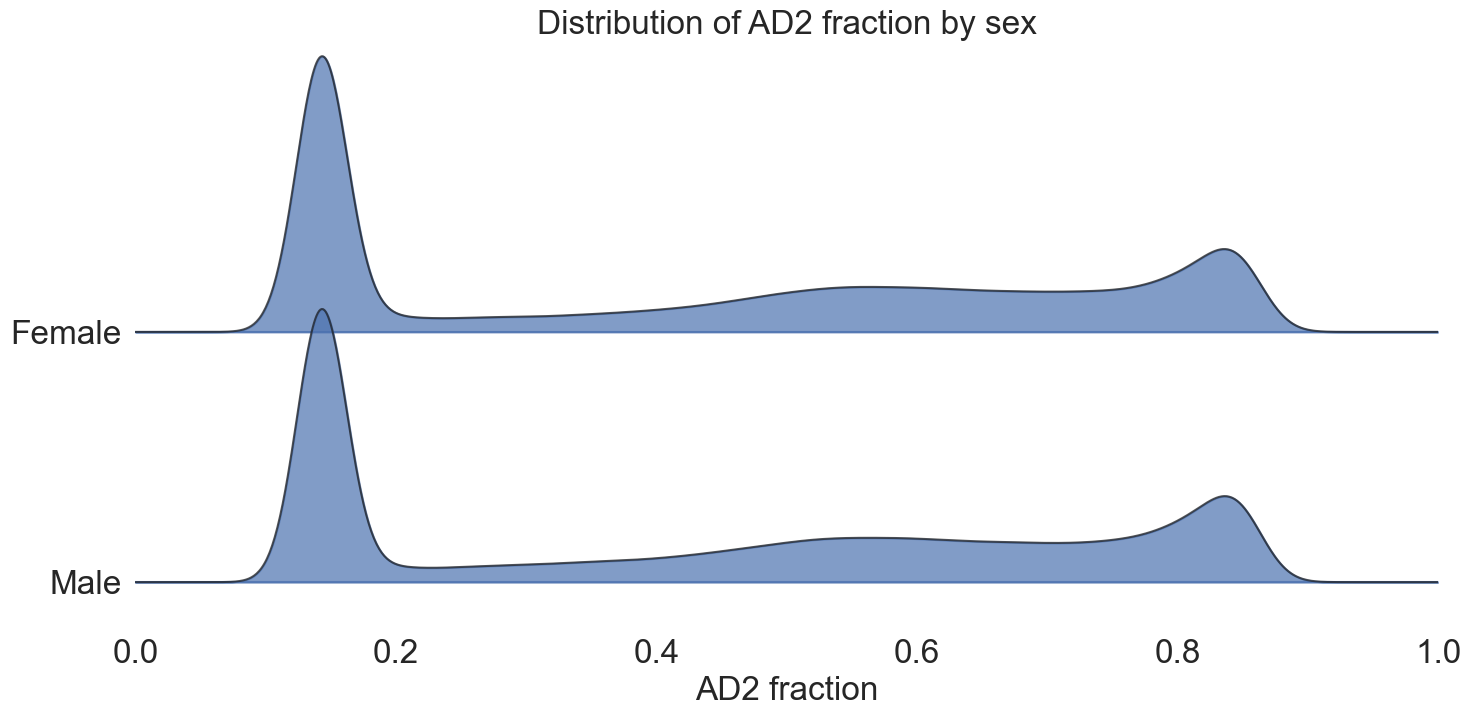

In [97]:
plt.figure(figsize=(6, 4))

joypy.joyplot(
    data=ad_df,#[(ad_df['AD1_frac']>=0.1) & (ad_df['AD1_frac']<=0.9)],
    by='sex',          # one ridge per sex
    column='AD1_frac', # variable to plot
    kind='kde',        # smooth distribution
    overlap=0.5,
    alpha=0.7,
    linewidth=1.5
)

plt.xlabel('AD2 fraction')
plt.title('Distribution of AD2 fraction by sex')
plt.xlim(0, 1)  # AD2_frac is bounded
plt.show()

In [98]:
groups = [
    ('Female', 'A'),
    ('Female', 'X'),
    ('Male', 'A'),
    ('Male', 'X')
]

colors = {'A': 'darkgray', 'X': 'teal'}
labels = {
    ('Female', 'A'): 'Female – Autosomes',
    ('Female', 'X'): 'Female – X',
    ('Male', 'A'): 'Male – Autosomes',
    ('Male', 'X'): 'Male – X'
}

<Figure size 600x500 with 0 Axes>

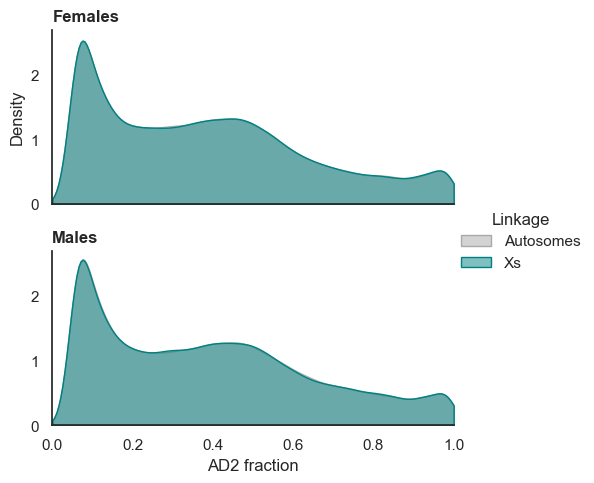

In [113]:
sns.set(style="white")

plt.figure(figsize=(6, 5))

g = sns.FacetGrid(
    ad_df[(ad_df['AD1_frac']>0) & (ad_df['AD2_frac']>0)],
    row='sex',
    hue='linkage',
    sharex=True,
    sharey=True,
    height=2.5,
    aspect=2,
    palette={'Autosomes': 'darkgray', 'Xs': 'teal'}  # adjust if your labels differ
)

g.map(
    sns.kdeplot,
    'AD2_frac',
    fill=True,
    alpha=0.5,
    clip=(0, 1)  # important for allele fractions
)

g.add_legend(title='Linkage')
g.set(xlim=(0, 1))
new_titles = {
    'Female': 'Females',
    'Male': 'Males'
}

g.set_titles('')
for ax, label in zip(g.axes.flat, df['sex'].unique()):
    ax.set_title(new_titles[label], loc='left', fontsize=12, weight='bold')

# Axis labels
g.set_axis_labels('AD2 fraction', 'Density')

# Keep only the middle y-axis label (optional but matches your style)
axes = g.axes.flatten()
for i, ax in enumerate(axes):
    if i == 0:  # top subplot only (since only 2 rows)
        ax.set_ylabel('Density', fontsize=12)
    else:
        ax.set_ylabel('')

# Save
plt.savefig("PLACEHOLDER_AD2_frac_sex_linkage_kde.png", dpi=300, bbox_inches='tight')
plt.savefig("PLACEHOLDER_AD2_frac_sex_linkage_kde.pdf", bbox_inches='tight')

plt.show()

In [101]:
ad_df

,file,AD1,AD2,sample,AD1_frac,AD2_frac,sex,sum,linkage
0,AF_F_10.AD.csv,9,20,AF_F_10,0.310345,0.689655,Female,29,Autosomes
1,AF_F_10.AD.csv,5,8,AF_F_10,0.384615,0.615385,Female,13,Xs
2,AF_F_10.AD.csv,0,12,AF_F_10,0.000000,1.000000,Female,12,Autosomes
3,AF_F_10.AD.csv,13,10,AF_F_10,0.565217,0.434783,Female,23,Xs
4,AF_F_10.AD.csv,0,28,AF_F_10,0.000000,1.000000,Female,28,Autosomes
...,...,...,...,...,...,...,...,...,...
1069497,AF_M_9.AD.csv,8,2,AF_M_9,0.800000,0.200000,Male,10,Xs
1069498,AF_M_9.AD.csv,0,117,AF_M_9,0.000000,1.000000,Male,117,Autosomes
1069499,AF_M_9.AD.csv,0,14,AF_M_9,0.000000,1.000000,Male,14,Xs
1069500,AF_M_9.AD.csv,0,182,AF_M_9,0.000000,1.000000,Male,182,Autosomes


<Figure size 600x600 with 0 Axes>

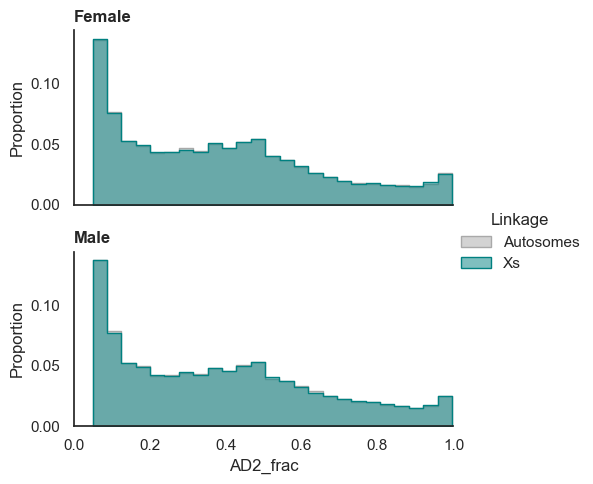

In [114]:
sns.set(style="white")

plt.figure(figsize=(6,6))
g = sns.FacetGrid(ad_df[(ad_df['AD1_frac']>0) & (ad_df['AD2_frac']>0)], 
                  row='sex', 
                  hue='linkage', 
                  sharex=True, 
                  sharey=True,
                  height=2.5, 
                  aspect=2,
                  palette={'Autosomes': 'darkgray', 'Xs': 'teal'}
                 )
g.map(
    sns.histplot,
    'AD2_frac',
    bins=25,
    stat='proportion',
    element='step',
    fill=True,
    alpha=0.5
)
g.add_legend(title='Linkage')
g.set(xlim=(0, 1))

g.set_titles('')
for ax, label in zip(g.axes.flat, ad_df['sex'].unique()):
    ax.set_title(label, loc='left', fontsize=12, weight='bold')

plt.savefig("PLACEHOLDER_AD2_frac_sex_linkage_hist.png", dpi=300, bbox_inches='tight')
plt.savefig("PLACEHOLDER_AD2_frac_sex_linkage_hist.png", bbox_inches='tight')
plt.show()